In [1]:
!pip install pandas geopandas folium branca
!pip install matplotlib
!pip install scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

In [3]:
clean_india_fires = pd.read_csv("C:/Users/nekos/geo876-final-project/geo876-final-project/data/processed/clean_india_fires.csv")

clean_india_fires.head()

,latitude,longitude,frp,daynight,datetime
0,12.32213,79.80682,5.51,D,2026-05-17 07:54:00
1,14.91190,78.05463,7.36,D,2026-05-17 07:54:00
2,14.92774,78.13425,5.84,D,2026-05-17 07:54:00
3,14.93009,78.83564,5.10,D,2026-05-17 07:54:00
4,14.93350,78.82936,6.09,D,2026-05-17 07:54:00


In [4]:
#Normalising the data so that one strong fire does not overpower the others
clean_india_fires["frp_norm"] = clean_india_fires["frp"] / clean_india_fires["frp"].max()
HeatMapData = clean_india_fires[["latitude", "longitude", "frp_norm"]].values.tolist()

In [5]:
clean_india_fires["datetime"] = pd.to_datetime(clean_india_fires["datetime"]) 
clean_india_fires["date"] = clean_india_fires["datetime"].dt.date

In [6]:
#Map of the fire points and the kernel density
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
india_boundary = world[world["ADMIN"] == "India"]

In [7]:
india_fires_map = LinearSegmentedColormap.from_list(
    "fire_scale",
    ["#ffffff", "#fff7bc", "#fec44f", "#f03b20", "#bd0026"]
)

In [8]:
def plot_fire_points(clean_india_fires, target_date):

    d = clean_india_fires[clean_india_fires["date"] == target_date].copy()

    if len(d) < 5:
        print(f"Skipping {target_date} (not enough data)")
        return

    x = d["longitude"].values
    y = d["latitude"].values
    w = d["frp_norm"].values

    fig, ax = plt.subplots(figsize=(9, 8))

    india_boundary.plot(
        ax=ax,
        color="black",
        edgecolor="black",
        linewidth=1
    )

    sc = ax.scatter(
        x, y,
        c=w,
        cmap=india_fires_map,
        s=15,
        edgecolor="none", 
        vmin=0,
        vmax=1
    )

    plt.title(f"Fire Points in India on {target_date}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.colorbar(sc, ax=ax, label="FRP (normalised)")

    save_path = f"C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fire_points_{target_date}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

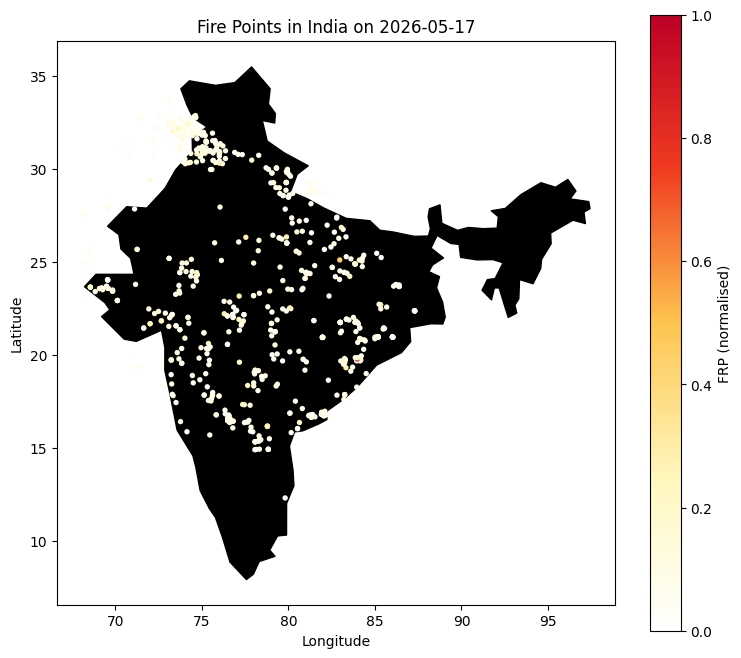

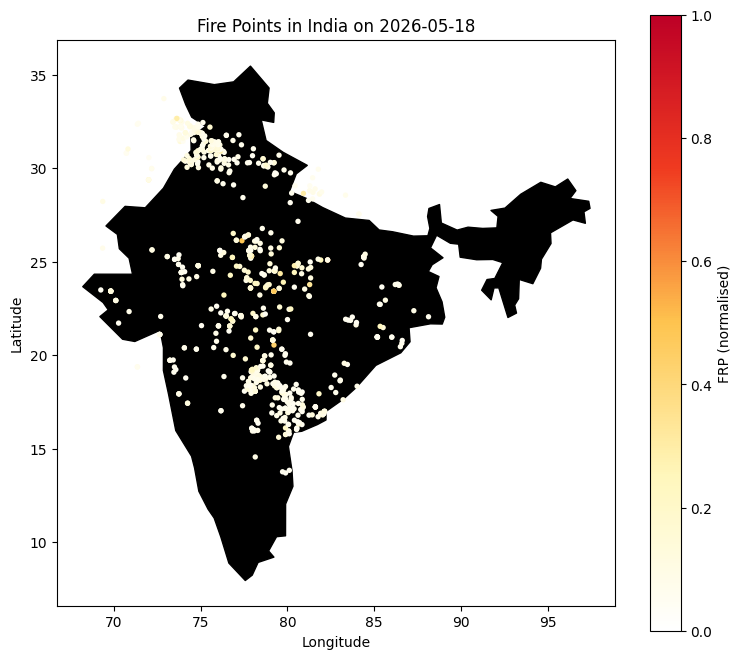

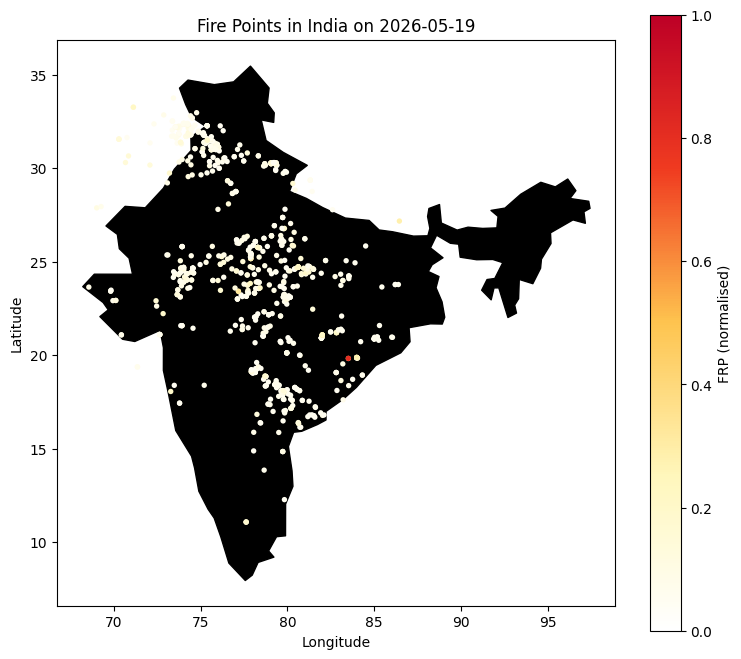

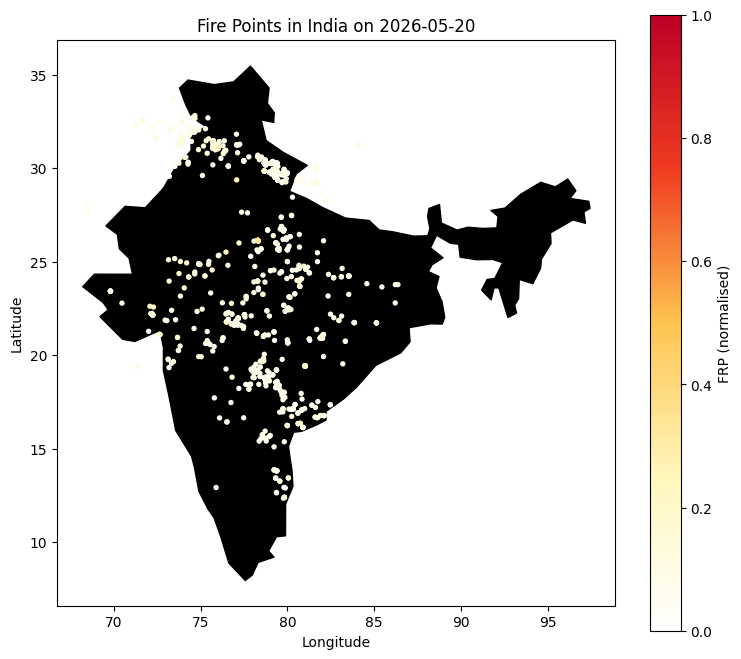

Skipping 2026-05-21 (not enough data)


In [9]:
for d in clean_india_fires["date"].unique():
    plot_fire_points(clean_india_fires, d)

In [10]:
#Kernel density maps
#global variable to store max across all days
global_max_kde = None


def compute_global_kde_max(clean_india_fires):
    global global_max_kde

    if global_max_kde is not None:
        return global_max_kde

    all_max = 0

    for d in clean_india_fires["date"].unique():
        df = clean_india_fires[clean_india_fires["date"] == d].copy()

        if len(df) < 5:
            continue

        x = df["longitude"].values
        y = df["latitude"].values
        w = df["frp_norm"].values

        if x.min() == x.max() or y.min() == y.max():
            continue

        xi, yi = np.mgrid[
            x.min():x.max():200j,
            y.min():y.max():200j
        ]

        coords = np.vstack([x, y])
        grid_coords = np.vstack([xi.ravel(), yi.ravel()])

        kde = gaussian_kde(coords, weights=w, bw_method=0.2)
        zi = kde(grid_coords).reshape(xi.shape)

        all_max = max(all_max, zi.max())

    global_max_kde = all_max
    return global_max_kde


def plot_kde_day(clean_india_fires, target_date):

    d = clean_india_fires[clean_india_fires["date"] == target_date].copy()

    # safety check
    if len(d) < 5:
        print(f"Skipping {target_date} (not enough data)")
        return

    x = d["longitude"].values
    y = d["latitude"].values
    w = d["frp_norm"].values

    # avoid crash if all points identical range
    if x.min() == x.max() or y.min() == y.max():
        print(f"Skipping {target_date} (zero spatial variation)")
        return

    # grid
    xi, yi = np.mgrid[
        x.min():x.max():200j,
        y.min():y.max():200j
    ]

    coords = np.vstack([x, y])
    grid_coords = np.vstack([xi.ravel(), yi.ravel()])

    # weighted KDE
    kde = gaussian_kde(coords, weights=w, bw_method=0.2)
    zi = kde(grid_coords).reshape(xi.shape)

    #Get global max 
    global_max = compute_global_kde_max(clean_india_fires)

    # plot
    fig, ax = plt.subplots(figsize=(9, 8))
    india_boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
    plt.title(f"Most Severe Fires in India on {target_date}")

    img = plt.imshow(
        np.rot90(zi),
        cmap=india_fires_map,
        extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="auto",
        vmin=0,
        vmax=global_max   
    )

    plt.colorbar(img, label="FRP intensity (normalised)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    save_path = f"C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_{target_date}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    print("Saved:", save_path)

    plt.show()

Saved: C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_2026-05-17.png


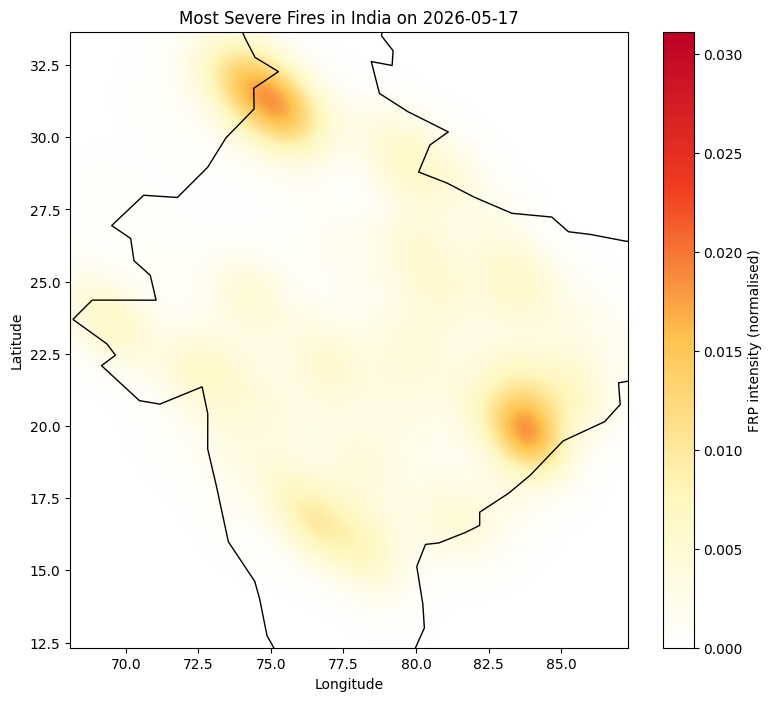

Saved: C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_2026-05-18.png


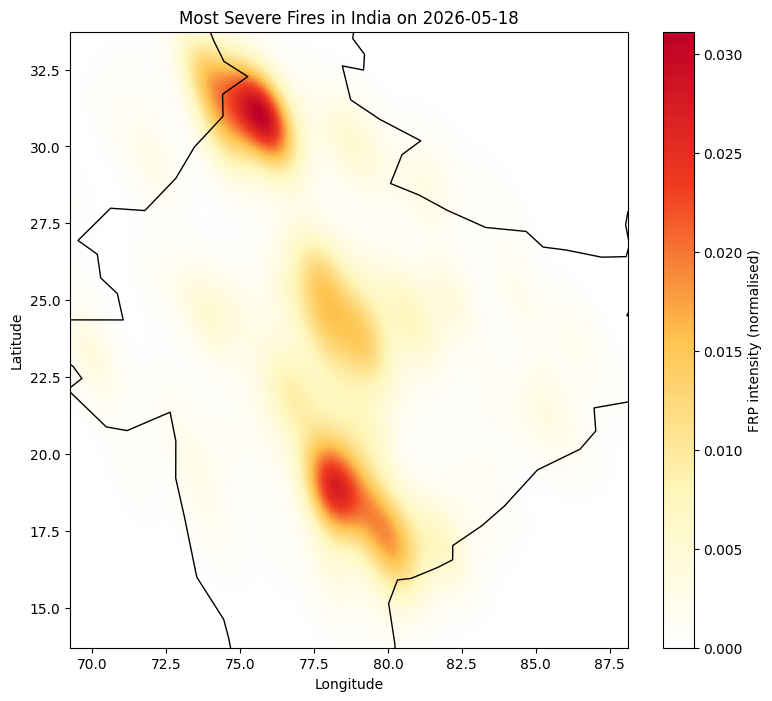

Saved: C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_2026-05-19.png


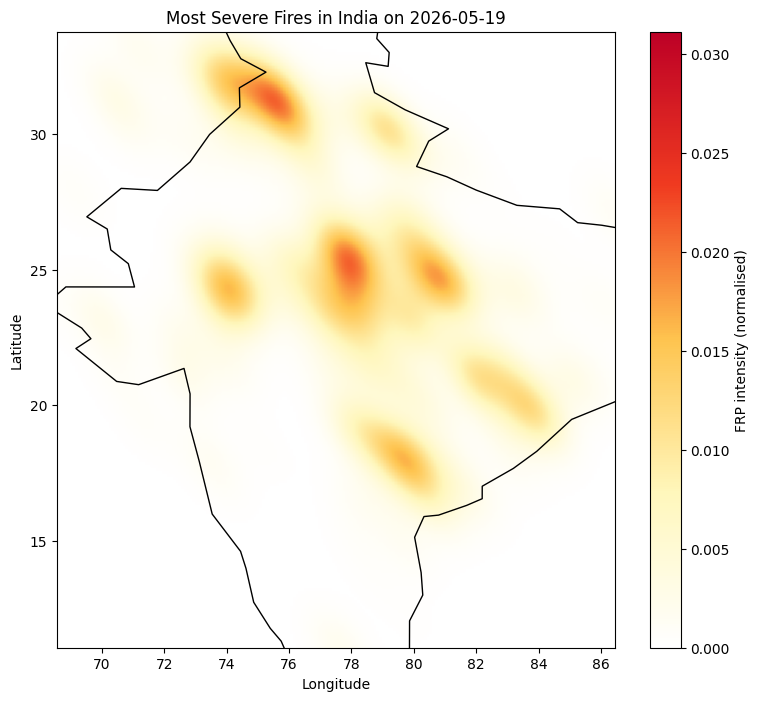

Saved: C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_2026-05-20.png


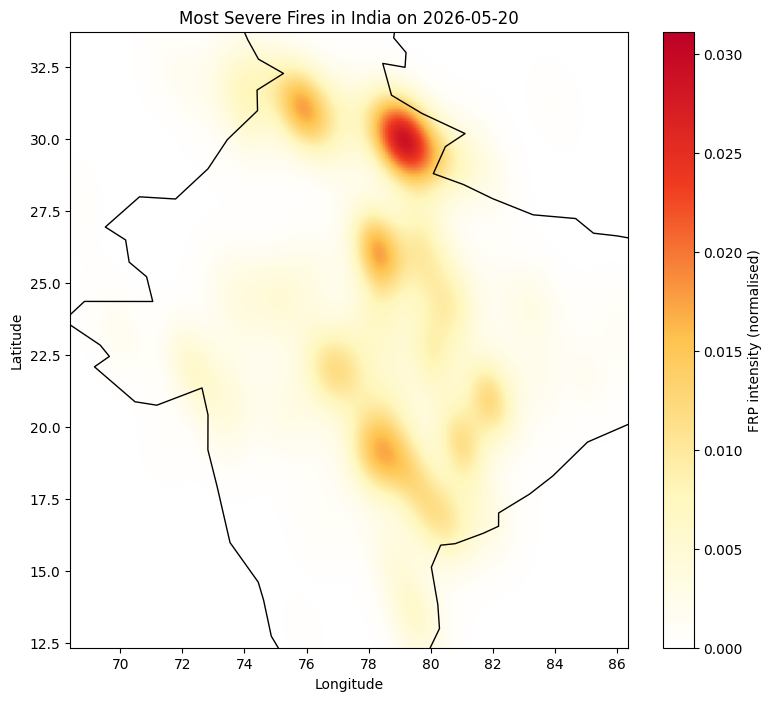

Skipping 2026-05-21 (not enough data)


In [11]:
for d in clean_india_fires["date"].unique():
    plot_kde_day(clean_india_fires, d)